In [ ]:
!pip install tensorflow

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
max_words=5000, max_len=500, batch_size=64, embed_dim=32
Train fragments: 29978, Test fragments: 7492
Epoch 1/15


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.1258 - loss: 2.8430 - val_accuracy: 0.0000e+00 - val_loss: 7.7623
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.1810 - loss: 2.6622 - val_accuracy: 0.0000e+00 - val_loss: 9.1774
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.2291 - loss: 2.4453 - val_accuracy: 0.0000e+00 - val_loss: 11.1469
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.2651 - loss: 2.3069 - val_accuracy: 0.0157 - val_loss: 10.4363
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.3323 - loss: 2.0360 - val_accuracy: 0.0254 - val_loss: 14.8634
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.4138 - loss: 1.6958 - val_accuracy: 0.0887 - val_loss: 18.1411
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.5182 - loss: 1.3783 - val_accuracy: 0.0717 - val_loss: 20.5832
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.5900 - loss: 1.1357 

,Метрика,Значение
0,Точность,0.55
1,Precision (macro),0.47
2,Recall (macro),0.51
3,F1-score (macro),0.48


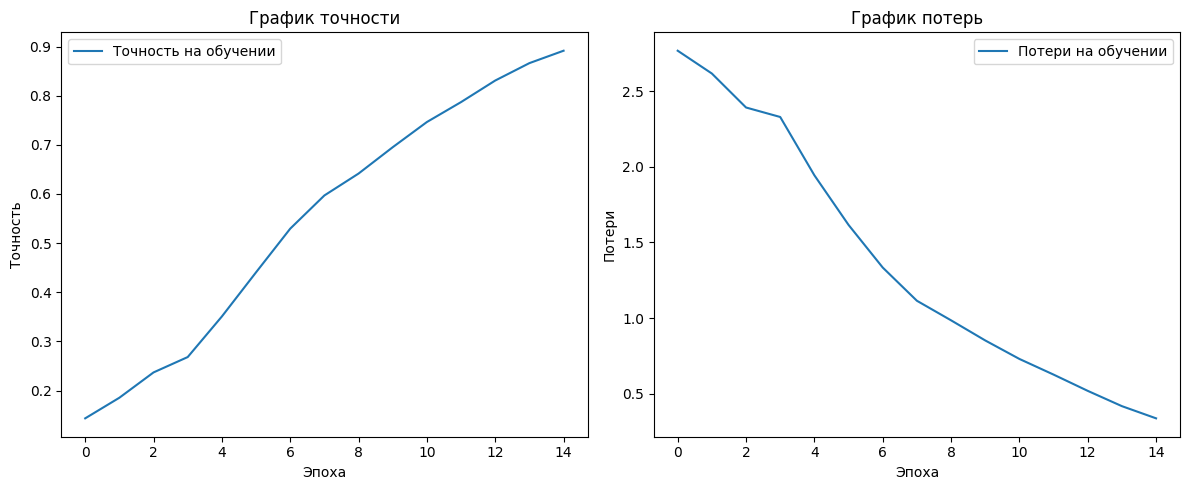

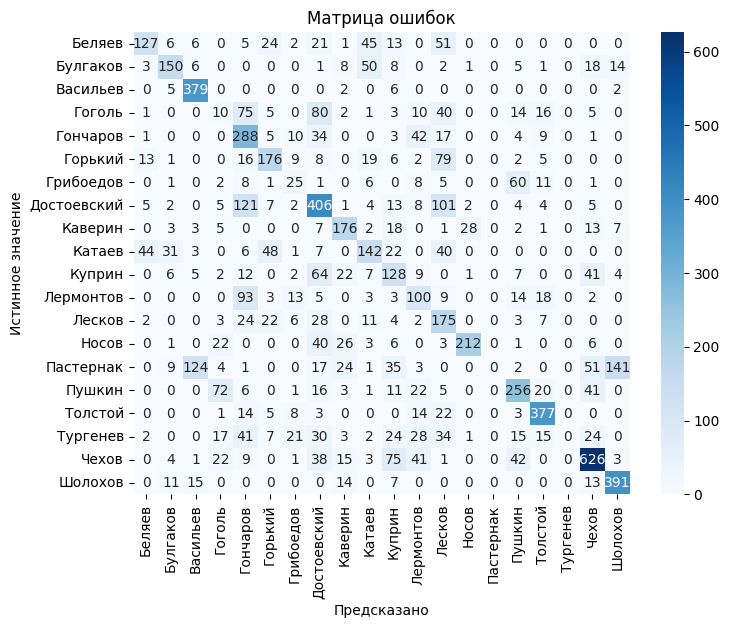

,Full files,Fragments
Author,,
Беляев,1,1203
Булгаков,1,1067
Васильев,1,1575
Гоголь,1,1048
Гончаров,1,1656
Горький,1,1346
Грибоедов,1,517
Достоевский,1,2762
Каверин,1,1063


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import numpy as np
from collections import Counter
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, precision_recall_fscore_support
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense, LSTM
try:
    # Попытка использовать оптимизированный CuDNNLSTM (работает на GPU)
    from tensorflow.keras.layers import CuDNNLSTM as FastLSTM
    LSTM_LAYER = FastLSTM
except ImportError:
    # fallback на обычный LSTM
    LSTM_LAYER = LSTM
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from google.colab import drive

# Настройка matplotlib для кириллицы
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['axes.unicode_minus'] = False

def read_full_texts(folder_path, prefix='train_'):
    texts, labels = [], []
    for fn in os.listdir(folder_path):
        if fn.startswith(prefix) and fn.endswith('.txt'):
            author = fn[len(prefix):-4]
            path = os.path.join(folder_path, fn)
            try:
                with open(path, 'r', encoding='utf-8') as f:
                    texts.append(f.read())
            except UnicodeDecodeError:
                with open(path, 'r', encoding='cp1251') as f:
                    texts.append(f.read())
            labels.append(author)
    return texts, labels

def split_into_fixed_fragments(texts, labels, fragment_len=1500, min_len=1000):
    frags, frag_labels = [], []
    for txt, lab in zip(texts, labels):
        for i in range(0, len(txt), fragment_len):
            frag = txt[i:i+fragment_len]
            if len(frag) >= min_len:
                frags.append(frag)
                frag_labels.append(lab)
    return frags, frag_labels

def plot_metrics(history):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Точность на обучении')
    plt.title('График точности'); plt.xlabel('Эпоха'); plt.ylabel('Точность'); plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Потери на обучении')
    plt.title('График потерь'); plt.xlabel('Эпоха'); plt.ylabel('Потери'); plt.legend()
    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(y_true, y_pred, labels):
    cm = confusion_matrix(y_true, y_pred, labels=range(len(labels)))
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=labels, yticklabels=labels, cmap='Blues')
    plt.xlabel('Предсказано'); plt.ylabel('Истинное значение')
    plt.title('Матрица ошибок')
    plt.show()

def print_key_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0)
    df = pd.DataFrame({
        'Метрика': ['Точность', 'Precision (macro)', 'Recall (macro)', 'F1-score (macro)'],
        'Значение': [f"{acc:.2f}", f"{precision:.2f}", f"{recall:.2f}", f"{f1:.2f}"]
    })
    display(df)

if __name__ == '__main__':
    drive.mount('/content/drive')
    base = '/content/drive/MyDrive/Colab Notebooks/Lab_6/Выборка'

    # 1) Считываем тексты
    train_texts_full, train_labels_full = read_full_texts(os.path.join(base, 'Train'), 'train_')
    test_texts_full,  test_labels_full  = read_full_texts(os.path.join(base,  'Test'), 'test_')

    # 2) Фрагментация
    train_texts, train_labels = split_into_fixed_fragments(train_texts_full, train_labels_full)
    test_texts,  test_labels  = split_into_fixed_fragments(test_texts_full,  test_labels_full)

    # 3) Параметры
    max_words = 5000
    max_len   = 500    # сократили длину последовательности
    batch_size = 64    # увеличили batch size
    embed_dim  = 32    # уменьшили размер эмбеддинга

    print(f"max_words={max_words}, max_len={max_len}, batch_size={batch_size}, embed_dim={embed_dim}")
    print(f"Train fragments: {len(train_texts)}, Test fragments: {len(test_texts)}")

    # 4) Токенизация и паддинг
    tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
    tokenizer.fit_on_texts(train_texts)
    X_train = pad_sequences(tokenizer.texts_to_sequences(train_texts),
                            maxlen=max_len, padding='post')
    X_test  = pad_sequences(tokenizer.texts_to_sequences(test_texts),
                            maxlen=max_len, padding='post')

    # 5) Кодируем метки
    le      = LabelEncoder()
    y_train = to_categorical(le.fit_transform(train_labels))
    y_test  = to_categorical(le.transform(test_labels))

    # 6) Модель Embedding + (CuDNN)LSTM
    model = Sequential([
        Embedding(input_dim=max_words, output_dim=embed_dim, input_length=max_len, mask_zero=True),
        LSTM_LAYER(64, return_sequences=False),
        Dense(32, activation='relu'),
        Dense(y_train.shape[1], activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    # 7) Обучение
    history = model.fit(X_train, y_train, epochs=15, batch_size=batch_size, validation_split=0.1)

    # 8) Оценка
    y_pred = np.argmax(model.predict(X_test, batch_size=batch_size), axis=1)
    y_true = np.argmax(y_test, axis=1)

    print_key_metrics(y_true, y_pred)
    plot_metrics(history)
    plot_confusion_matrix(y_true, y_pred, le.classes_)

    # 9) Статистика фрагментов
    df_counts = pd.DataFrame({
        'Full files': Counter(train_labels_full),
        'Fragments': Counter(train_labels)
    }).fillna(0).astype(int).sort_index()
    df_counts.index.name = 'Author'
    display(df_counts)
